# Stock Market Return Prediction Using Regression Models

## Problem Statement

The objective of this regression track is to predict the next trading day's
log return using historical stock-market information.

The dataset contains daily OHLCV data for four companies from different
sectors:

- AAPL — Technology
- BA — Industrials
- JPM — Financials
- KO — Consumer Staples

The stocks were selected to represent different market sectors while keeping
the dataset computationally manageable.

The target variable is the next-day log return.

In [33]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [34]:
df = pd.read_csv("djia4_regression_data.csv")

df.head()

,Date,Open,High,Low,Close,Volume,Ticker
0,04-01-2006,10.73,10.85,10.64,10.71,155225609,AAPL
1,05-01-2006,10.69,10.70,10.54,10.63,112396081,AAPL
2,06-01-2006,10.75,10.96,10.65,10.90,176139334,AAPL
3,09-01-2006,10.96,11.03,10.82,10.86,168861224,AAPL
4,10-01-2006,10.89,11.70,10.83,11.55,570088246,AAPL


In [35]:
df.shape

(12071, 7)

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12071 entries, 0 to 12070
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    12071 non-null  str    
 1   Open    12071 non-null  float64
 2   High    12071 non-null  float64
 3   Low     12071 non-null  float64
 4   Close   12071 non-null  float64
 5   Volume  12071 non-null  int64  
 6   Ticker  12071 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 660.3 KB


In [37]:
df.describe()

,Open,High,Low,Close,Volume
count,12071.000000,12071.000000,12071.000000,12071.000000,1.207100e+04
mean,62.894696,63.459454,62.289549,62.893897,4.533225e+07
std,41.850361,42.113574,41.558776,41.853337,7.255998e+07
min,7.390000,7.560000,7.170000,7.240000,3.616020e+05
25%,35.875000,36.400000,35.240000,35.865000,8.470094e+06
50%,47.070000,47.500000,46.540000,47.010000,1.678240e+07
75%,80.345000,81.150000,79.450000,80.205000,4.214102e+07
max,298.700000,299.330000,297.110000,297.900000,8.432640e+08


In [38]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

df.head(15)

,Date,Open,High,Low,Close,Volume,Ticker
0,2006-01-04,10.73,10.85,10.64,10.71,155225609,AAPL
1,2006-01-05,10.69,10.70,10.54,10.63,112396081,AAPL
2,2006-01-06,10.75,10.96,10.65,10.90,176139334,AAPL
3,2006-01-09,10.96,11.03,10.82,10.86,168861224,AAPL
4,2006-01-10,10.89,11.70,10.83,11.55,570088246,AAPL
5,2006-01-11,11.98,12.11,11.80,11.99,373548882,AAPL
6,2006-01-12,12.14,12.34,11.95,12.04,320201966,AAPL
7,2006-01-13,12.14,12.29,12.09,12.23,194153393,AAPL
8,2006-01-17,12.24,12.34,11.98,12.10,209215265,AAPL
9,2006-01-18,11.87,12.01,11.69,11.78,303279501,AAPL


In [39]:
df["Date"].dtype

dtype('<M8[us]')

In [40]:
df.groupby("Ticker")["Date"].agg(["min", "max", "count"])

,min,max,count
Ticker,,,
AAPL,2006-01-04,2017-12-28,3017
BA,2006-01-04,2017-12-28,3018
JPM,2006-01-04,2017-12-28,3018
KO,2006-01-04,2017-12-28,3018


This indicates that AAPL is missing a value, hence we can handle this missing value.

In [41]:
date_counts = df.groupby("Date")["Ticker"].nunique()

incomplete_dates = date_counts[date_counts < 4]

incomplete_dates

Date
2010-04-01    3
Name: Ticker, dtype: int64

In [42]:
for date in incomplete_dates.index:

    present = df.loc[df["Date"] == date, "Ticker"].tolist()

    print(date, "Present:", present)

2010-04-01 00:00:00 Present: ['BA', 'JPM', 'KO']


### Observation: Ticker-wise Date Coverage

All four stocks cover the same overall period from January 2006 to December 2017.
However, AAPL contains 3017 observations, while BA, JPM, and KO contain 3018 observations.

Further inspection showed that the AAPL observation for 2010-04-01 is absent,
while the other three stocks contain data for this date.

The missing AAPL value was not imputed, since generating an artificial stock
price could distort the return calculation. Instead, the return immediately
following this gap is treated as unavailable during feature engineering.

In [43]:
df["log_return"] = (
    df.groupby("Ticker")["Close"]
      .transform(lambda x: np.log(x / x.shift(1)))
)

In [44]:
missing_date = pd.Timestamp("2010-04-01")

next_aapl_date = df.loc[
    (df["Ticker"] == "AAPL") &
    (df["Date"] > missing_date),
    "Date"
].min()

next_aapl_date

Timestamp('2010-04-05 00:00:00')

In [45]:
df.loc[
    (df["Ticker"] == "AAPL") &
    (df["Date"] == next_aapl_date),
    "log_return"
] = np.nan

In [46]:
df["target_next_log_return"] = (
    df.groupby("Ticker")["log_return"]
      .shift(-1)
)

In [47]:
df[[
    "Date",
    "Ticker",
    "Close",
    "log_return",
    "target_next_log_return"
]].head(10)

,Date,Ticker,Close,log_return,target_next_log_return
0,2006-01-04,AAPL,10.71,NaN,-0.007498
1,2006-01-05,AAPL,10.63,-0.007498,0.025083
2,2006-01-06,AAPL,10.90,0.025083,-0.003676
3,2006-01-09,AAPL,10.86,-0.003676,0.061599
4,2006-01-10,AAPL,11.55,0.061599,0.037388
5,2006-01-11,AAPL,11.99,0.037388,0.004161
6,2006-01-12,AAPL,12.04,0.004161,0.015658
7,2006-01-13,AAPL,12.23,0.015658,-0.010686
8,2006-01-17,AAPL,12.10,-0.010686,-0.026802
9,2006-01-18,AAPL,11.78,-0.026802,-0.042486


In [48]:
df.groupby("Ticker").tail(2)[[
    "Date",
    "Ticker",
    "Close",
    "log_return",
    "target_next_log_return"
]]

,Date,Ticker,Close,log_return,target_next_log_return
3015,2017-12-27,AAPL,170.60,0.000176,0.002810
3016,2017-12-28,AAPL,171.08,0.002810,NaN
6033,2017-12-27,BA,295.62,0.000880,0.002466
6034,2017-12-28,BA,296.35,0.002466,NaN
9051,2017-12-27,JPM,107.22,0.001867,0.005302
9052,2017-12-28,JPM,107.79,0.005302,NaN
12069,2017-12-27,KO,45.93,0.002616,-0.004583
12070,2017-12-28,KO,45.72,-0.004583,NaN


## Feature Engineering

In [49]:
# Intraday price range
df["high_low_range"] = (
    (df["High"] - df["Low"]) / df["Open"]
)

# Open-to-close movement
df["open_close_change"] = (
    (df["Close"] - df["Open"]) / df["Open"]
)

# Previous day's return
df["lag_return_1"] = (
    df.groupby("Ticker")["log_return"]
      .shift(1)
)

# Return from two trading days ago
df["lag_return_2"] = (
    df.groupby("Ticker")["log_return"]
      .shift(2)
)

# 5-day rolling volatility
df["rolling_volatility_5"] = (
    df.groupby("Ticker")["log_return"]
      .transform(lambda x: x.rolling(5).std())
)

# Change in trading volume from previous trading day
df["volume_change"] = (
    df.groupby("Ticker")["Volume"]
      .pct_change()
)

In [50]:
df["ma_5"] = (
    df.groupby("Ticker")["Close"]
      .transform(lambda x: x.rolling(5).mean())
)

df["price_to_ma5"] = (
    df["Close"] / df["ma_5"] - 1
)

In [51]:
df.isnull().sum()

Date                       0
Open                       0
High                       0
Low                        0
Close                      0
Volume                     0
Ticker                     0
log_return                 5
target_next_log_return     5
high_low_range             0
open_close_change          0
lag_return_1               9
lag_return_2              13
rolling_volatility_5      25
volume_change              4
ma_5                      16
price_to_ma5              16
dtype: int64

In [52]:
print("Final shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Final shape: (12071, 17)

Missing values:
Date                       0
Open                       0
High                       0
Low                        0
Close                      0
Volume                     0
Ticker                     0
log_return                 5
target_next_log_return     5
high_low_range             0
open_close_change          0
lag_return_1               9
lag_return_2              13
rolling_volatility_5      25
volume_change              4
ma_5                      16
price_to_ma5              16
dtype: int64


In [53]:
df = df.dropna().reset_index(drop=True)

In [54]:
print("Final shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Final shape: (12041, 17)

Missing values:
Date                      0
Open                      0
High                      0
Low                       0
Close                     0
Volume                    0
Ticker                    0
log_return                0
target_next_log_return    0
high_low_range            0
open_close_change         0
lag_return_1              0
lag_return_2              0
rolling_volatility_5      0
volume_change             0
ma_5                      0
price_to_ma5              0
dtype: int64


### Observation

After feature engineering, 30 observations were removed because lagged features,
rolling statistics, and the next-day target require sufficient previous or future
trading observations.

The dataset was reduced from 12,071 to 12,041 rows, corresponding to a loss of
approximately 0.25% of the observations. No missing values remain in the final
feature-engineered dataset.

## EDA Features

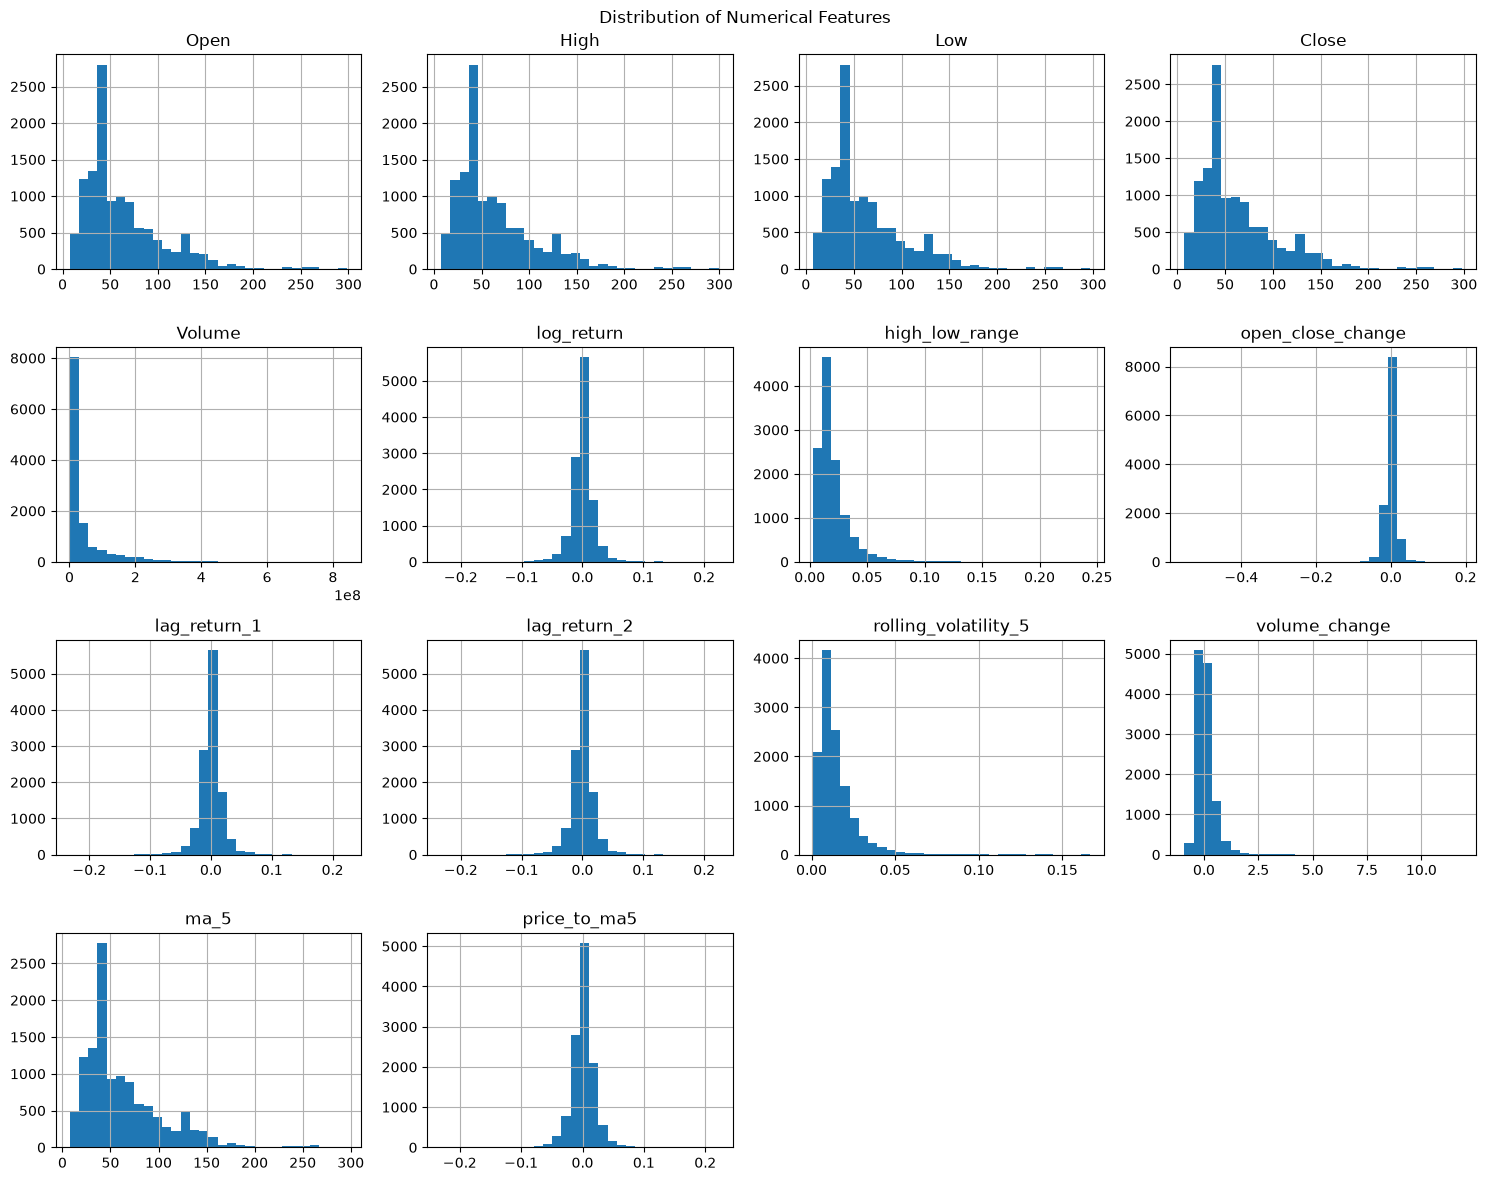

In [55]:
numeric_features = [
    "Open", "High", "Low", "Close", "Volume",
    "log_return",
    "high_low_range",
    "open_close_change",
    "lag_return_1",
    "lag_return_2",
    "rolling_volatility_5",
    "volume_change",
    "ma_5",
    "price_to_ma5"
]

df[numeric_features].hist(figsize=(15, 12), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

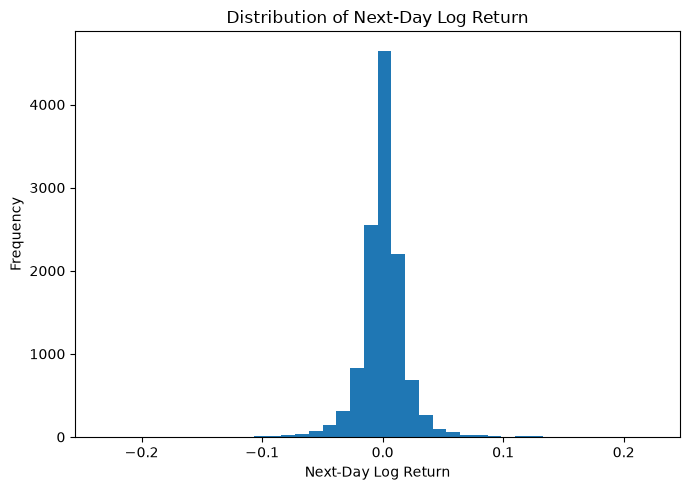

In [56]:
plt.figure(figsize=(7, 5))

plt.hist(df["target_next_log_return"], bins=40)

plt.title("Distribution of Next-Day Log Return")
plt.xlabel("Next-Day Log Return")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Observation

The next-day log returns are highly concentrated around zero, indicating that most daily stock price changes are relatively small. A few extreme positive and negative returns are also present, producing long tails in the distribution.

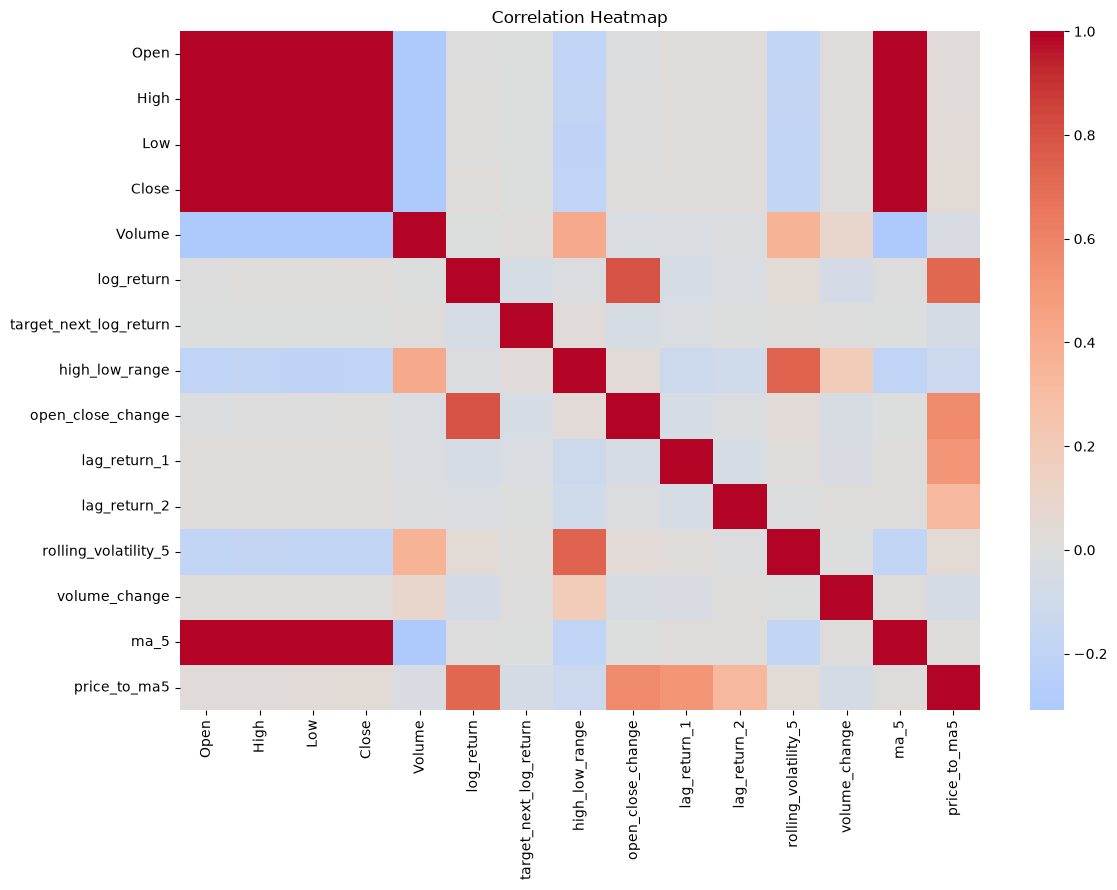

In [57]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Observation

The OHLC price variables and the 5-day moving average show strong positive correlations with each other, 
which is expected since they are derived from the same price series. The next-day log return shows relatively weak linear correlation with
most input features, indicating that next-day stock returns are difficult to predict using any single feature alone.

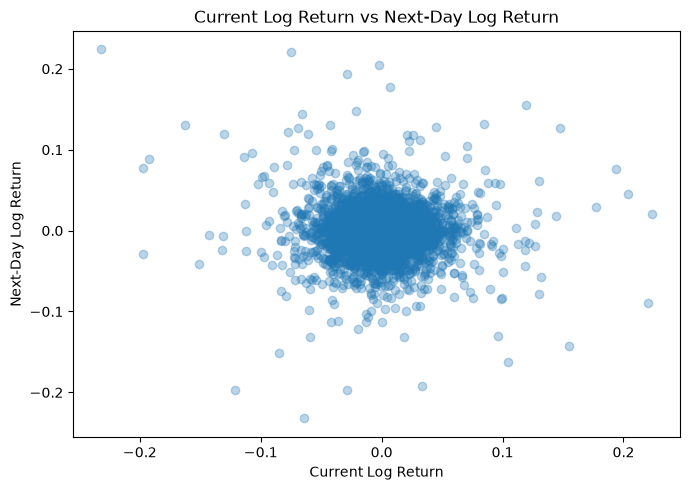

In [58]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["log_return"],
    df["target_next_log_return"],
    alpha=0.3
)

plt.title("Current Log Return vs Next-Day Log Return")
plt.xlabel("Current Log Return")
plt.ylabel("Next-Day Log Return")
plt.tight_layout()
plt.show()

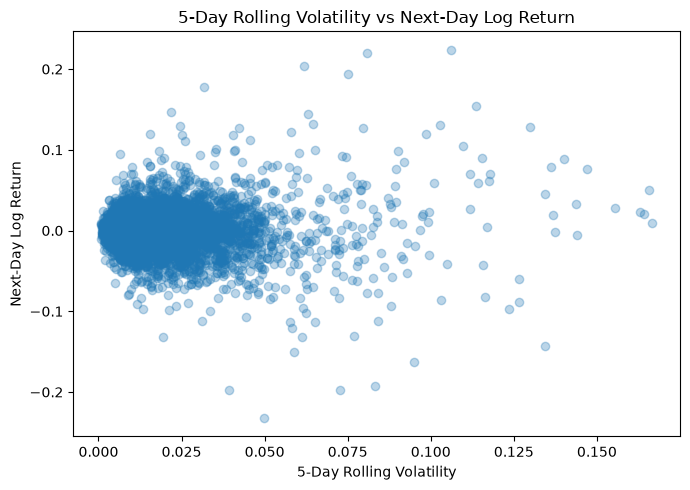

In [59]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["rolling_volatility_5"],
    df["target_next_log_return"],
    alpha=0.3
)

plt.title("5-Day Rolling Volatility vs Next-Day Log Return")
plt.xlabel("5-Day Rolling Volatility")
plt.ylabel("Next-Day Log Return")
plt.tight_layout()
plt.show()

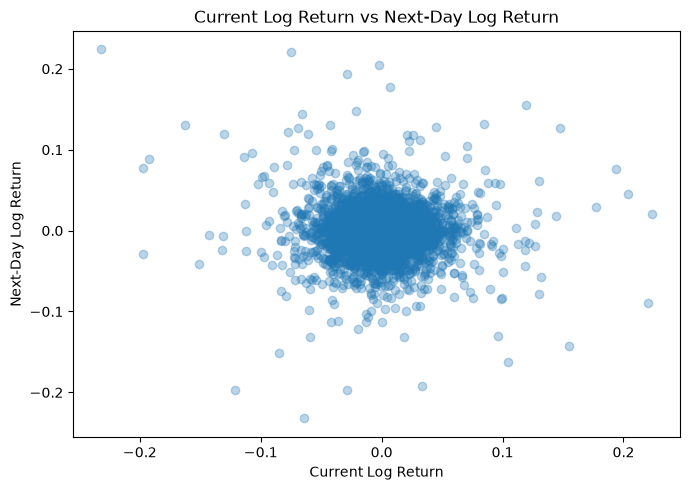

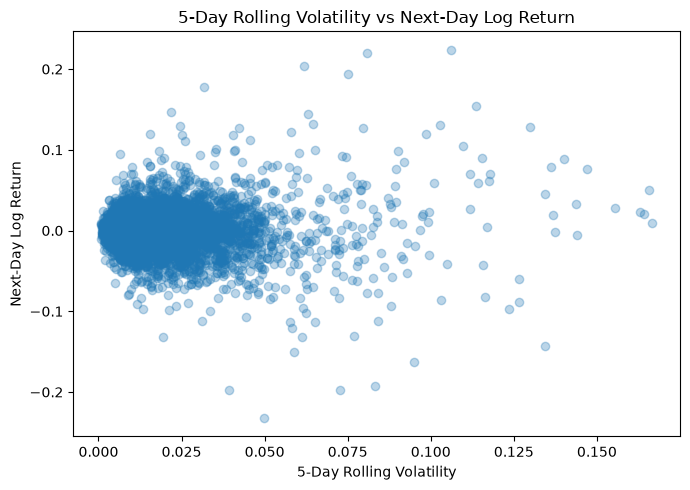

In [60]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df["log_return"],
    df["target_next_log_return"],
    alpha=0.3
)

plt.title("Current Log Return vs Next-Day Log Return")
plt.xlabel("Current Log Return")
plt.ylabel("Next-Day Log Return")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(
    df["rolling_volatility_5"],
    df["target_next_log_return"],
    alpha=0.3
)

plt.title("5-Day Rolling Volatility vs Next-Day Log Return")
plt.xlabel("5-Day Rolling Volatility")
plt.ylabel("Next-Day Log Return")
plt.tight_layout()
plt.show()

### Observation

The scatter plot of current log return against next-day log return shows no clear
linear relationship, with most observations concentrated around zero.

Similarly, 5-day rolling volatility does not show a strong direct relationship
with the next-day return, although the spread of returns tends to increase during
periods of higher volatility.

In [61]:
outlier_cols = [
    "log_return",
    "target_next_log_return",
    "high_low_range",
    "open_close_change",
    "rolling_volatility_5",
    "volume_change"
]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {count} outliers")

log_return: 907 outliers
target_next_log_return: 908 outliers
high_low_range: 812 outliers
open_close_change: 808 outliers
rolling_volatility_5: 730 outliers
volume_change: 487 outliers


### Outlier Handling

The IQR method identified several outliers in the return, volatility, price-range,
and volume-related features. These observations were retained because extreme
market movements can represent genuine financial events rather than data errors.

Instead of removing them, robust scaling will be used later for scale-sensitive
regression models to reduce the influence of extreme feature values.

In [62]:
# Sort once more by date
df = df.sort_values("Date").reset_index(drop=True)

# 80% train, 20% test
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print("Training period:",
      train_df["Date"].min(), "to", train_df["Date"].max())

print("Testing period:",
      test_df["Date"].min(), "to", test_df["Date"].max())

print("\nTrain shape:", train_df.shape)
print("Test shape:", test_df.shape)

Training period: 2006-01-11 00:00:00 to 2015-08-07 00:00:00
Testing period: 2015-08-07 00:00:00 to 2017-12-27 00:00:00

Train shape: (9632, 17)
Test shape: (2409, 17)


In [63]:
print(train_df["Ticker"].value_counts())
print()
print(test_df["Ticker"].value_counts())

Ticker
KO      2410
JPM     2410
BA      2410
AAPL    2402
Name: count, dtype: int64

Ticker
AAPL    603
JPM     602
BA      602
KO      602
Name: count, dtype: int64


In [64]:
feature_cols = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Ticker",
    "log_return",
    "high_low_range",
    "open_close_change",
    "lag_return_1",
    "lag_return_2",
    "rolling_volatility_5",
    "volume_change",
    "ma_5",
    "price_to_ma5"
]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df["target_next_log_return"]
y_test = test_df["target_next_log_return"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (9632, 15)
X_test: (2409, 15)
y_train: (9632,)
y_test: (2409,)


In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

numeric_cols = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "log_return",
    "high_low_range",
    "open_close_change",
    "lag_return_1",
    "lag_return_2",
    "rolling_volatility_5",
    "volume_change",
    "ma_5",
    "price_to_ma5"
]

categorical_cols = ["Ticker"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore",
                              sparse_output=False), categorical_cols)
    ]
)

# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Use the already-fitted preprocessor on test data
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train:", X_train_processed.shape)
print("Processed X_test:", X_test_processed.shape)

Processed X_train: (9632, 17)
Processed X_test: (2409, 17)


## Train-Test Split

Since stock-market observations are time-dependent, a random train-test split
could allow the model to learn from future observations and be evaluated on
earlier observations, leading to temporal data leakage.

Therefore, the dataset was sorted chronologically and split using an 80:20
ratio, with the earliest 80% used for training and the most recent 20% used for
testing. This preserves the temporal ordering of the data and better reflects a
real-world forecasting scenario.

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Train model
linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)

# Predictions
y_pred_linear = linear_model.predict(X_test_processed)

# Evaluation
linear_r2 = r2_score(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_mae = mean_absolute_error(y_test, y_pred_linear)

print("Linear Regression")
print("R²   :", linear_r2)
print("RMSE :", linear_rmse)
print("MAE  :", linear_mae)

Linear Regression
R²   : -0.049874629428362516
RMSE : 0.013083301683026016
MAE  : 0.008917500268418978


### Linear Regression Result

Linear Regression obtained an R² score of -0.0499, indicating that the model
does not explain the variation in next-day log returns effectively and performs
slightly worse than a mean-value baseline.

The RMSE was 0.01308 and the MAE was 0.00892. The weak performance is
consistent with the EDA, which showed limited linear relationships between the
selected historical features and next-day returns.

In [67]:
feature_names = preprocessor.get_feature_names_out()

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": linear_model.coef_
})

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
).drop(columns="Absolute_Coefficient")

,Feature,Coefficient
2,num__Low,0.176611
3,num__Close,-0.110476
12,num__ma_5,-0.052685
0,num__Open,-0.010273
1,num__High,-0.003725
15,cat__Ticker_JPM,-0.002554
16,cat__Ticker_KO,-0.002398
6,num__high_low_range,0.001810
14,cat__Ticker_BA,-0.001674
13,num__price_to_ma5,-0.001195


### Coefficient Interpretation

Among the scaled numerical features, `Low` has the largest positive coefficient,
while `Close` and `ma_5` have relatively large negative coefficients.

However, Open, High, Low, Close, and the moving average are strongly correlated,
so the individual coefficient values should be interpreted cautiously due to
multicollinearity.

The ticker coefficients are relatively small, suggesting that ticker identity
alone contributes little to the linear prediction. Overall, the negative R²
indicates that the linear model does not capture next-day return behaviour well.

In [68]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_processed, y_train)

y_pred_ridge = ridge_model.predict(X_test_processed)

ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("Ridge Regression")
print("R²   :", ridge_r2)
print("RMSE :", ridge_rmse)
print("MAE  :", ridge_mae)

Ridge Regression
R²   : -0.010199907879527847
RMSE : 0.012833712249287461
MAE  : 0.008745153363707615


### Ridge Regression Result

Ridge Regression improved slightly over Linear Regression, with a less negative
R² value and lower RMSE and MAE.

The result suggests that L2 regularization reduces some instability caused by
correlated features, but the model still has limited predictive ability for
next-day log returns.

In [69]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.0001)

lasso_model.fit(X_train_processed, y_train)

y_pred_lasso = lasso_model.predict(X_test_processed)

lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

print("Lasso Regression")
print("R²   :", lasso_r2)
print("RMSE :", lasso_rmse)
print("MAE  :", lasso_mae)

Lasso Regression
R²   : -0.002321617776179785
RMSE : 0.012783570882152949
MAE  : 0.008693827137290168


### Lasso Regression Result

Lasso Regression performed slightly better than Linear and Ridge Regression,
with an R² value closer to zero and lower RMSE and MAE.

The improvement suggests that L1 regularization helps reduce the effect of less
useful or redundant features.

In [70]:
feature_names = preprocessor.get_feature_names_out()

lasso_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso_model.coef_
})

print("Number of zero coefficients:",
      (lasso_model.coef_ == 0).sum())

lasso_coefficients

Number of zero coefficients: 11


,Feature,Coefficient
0,num__Open,-0.000078
1,num__High,-0.000000
2,num__Low,-0.000000
3,num__Close,-0.000000
4,num__Volume,0.000000
5,num__log_return,-0.000093
6,num__high_low_range,0.000283
7,num__open_close_change,-0.000592
8,num__lag_return_1,-0.000228
9,num__lag_return_2,0.000000


### Lasso Feature Sparsity

Lasso Regression reduced 11 of the 17 feature coefficients to zero. This
demonstrates the feature-selection property of L1 regularization, where less
useful or redundant features are eliminated from the model.

In [71]:
from sklearn.linear_model import ElasticNet

elastic_model = ElasticNet(
    alpha=0.0001,
    l1_ratio=0.5
)

elastic_model.fit(X_train_processed, y_train)

y_pred_elastic = elastic_model.predict(X_test_processed)

elastic_r2 = r2_score(y_test, y_pred_elastic)
elastic_rmse = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
elastic_mae = mean_absolute_error(y_test, y_pred_elastic)

print("ElasticNet Regression")
print("R²   :", elastic_r2)
print("RMSE :", elastic_rmse)
print("MAE  :", elastic_mae)

ElasticNet Regression
R²   : -0.004622830489840579
RMSE : 0.012798237257580032
MAE  : 0.008707597250422227


### ElasticNet Regression Result

ElasticNet performed slightly worse than Lasso but improved over the ordinary
Linear Regression model. Combining L1 and L2 regularization helped control the
effect of correlated and redundant features.

In [72]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

for degree in [2, 3]:

    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    # Fit only on training data
    X_train_poly = poly.fit_transform(X_train_processed)
    X_test_poly = poly.transform(X_test_processed)

    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)

    y_pred_poly = poly_model.predict(X_test_poly)

    poly_r2 = r2_score(y_test, y_pred_poly)
    poly_rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))
    poly_mae = mean_absolute_error(y_test, y_pred_poly)

    print(f"Polynomial Regression - Degree {degree}")
    print("R²   :", poly_r2)
    print("RMSE :", poly_rmse)
    print("MAE  :", poly_mae)
    print()

Polynomial Regression - Degree 2
R²   : -0.4888805221843129
RMSE : 0.015580398429678578
MAE  : 0.009975363997081

Polynomial Regression - Degree 3
R²   : -43.67046444132822
RMSE : 0.08534122435230189
MAE  : 0.02132612136099031



### Polynomial Regression Result

Polynomial Regression was evaluated using degrees 2 and 3.

Degree 2 produced an R² of -0.4889, while degree 3 performed substantially
worse with an R² of -43.6705.

The sharp decrease in performance for degree 3 indicates that increasing model
complexity does not improve generalization for this dataset and likely causes
overfitting. Therefore, degree 2 is retained as the representative Polynomial
Regression model for comparison with the other regression algorithms.

### 6. Decision Tree Regressor

A Decision Tree Regressor is used to model nonlinear relationships and to capture threshold-based splits in the features. The hyperparameter tuned here is the maximum depth, which controls the model complexity and helps reduce overfitting.

Feature importance is also extracted to identify which variables contribute most to the predictions.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

dt_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

dt_param_grid = {
    "model__max_depth": [None, 2, 3, 5, 7, 10, 15, 20]
}

dt_search = GridSearchCV(
    dt_pipe,
    dt_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
dt_search.fit(X_train, y_train)

best_dt = dt_search.best_estimator_
y_pred_dt = best_dt.predict(X_test)

dt_r2 = r2_score(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_mae = mean_absolute_error(y_test, y_pred_dt)

print("Decision Tree Regressor")
print("Best params:", dt_search.best_params_)
print("R²   :", dt_r2)
print("RMSE :", dt_rmse)
print("MAE  :", dt_mae)

dt_feature_importance = pd.DataFrame({
    "Feature": best_dt.named_steps["preprocess"].get_feature_names_out(),
    "Importance": best_dt.named_steps["model"].feature_importances_
})

dt_feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

### Decision Tree Interpretation

The tuned Decision Tree model is useful for identifying threshold-based patterns in the data, and the feature-importance output highlights which inputs contribute most to the splits. This helps explain the model, unlike many black-box alternatives. When the tree is too deep, it can overfit to short-term market noise; therefore, tuning max depth is essential.

### 7. Random Forest Regressor

Random Forest is an ensemble model that combines many decision trees. It reduces variance relative to a single tree and is often a strong baseline in tabular regression tasks. The key hyperparameter tuned here is the number of estimators, which controls how many trees are used in the ensemble.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(random_state=42)
rf_base.fit(X_train_processed, y_train)

y_pred_rf_base = rf_base.predict(X_test_processed)

rf_base_r2 = r2_score(y_test, y_pred_rf_base)
rf_base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_base))
rf_base_mae = mean_absolute_error(y_test, y_pred_rf_base)

print("Random Forest Baseline")
print("R²   :", rf_base_r2)
print("RMSE :", rf_base_rmse)
print("MAE  :", rf_base_mae)

rf_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_param_grid = {
    "model__n_estimators": [100, 200, 400, 800],
    "model__max_depth": [None, 5, 10, 15]
}

rf_search = GridSearchCV(
    rf_pipe,
    rf_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print()
print("Random Forest Tuned")
print("Best params:", rf_search.best_params_)
print("R²   :", rf_r2)
print("RMSE :", rf_rmse)
print("MAE  :", rf_mae)

Random Forest Baseline
R²   : -0.05430790299935495
RMSE : 0.013110895812944145
MAE  : 0.008989198175136284

Random Forest Tuned
Best params: {'model__max_depth': 5, 'model__n_estimators': 100}
R²   : -0.005052971455525412
RMSE : 0.012800976821538612
MAE  : 0.008703458275880947


### Random Forest Interpretation

The ensemble baseline already performs better than the single-tree model by reducing variance through averaging across multiple trees. Tuning the number of estimators shows whether a larger forest improves stability or simply adds computational cost without a meaningful gain. In many financial datasets, the gain over a well-regularized linear model is modest, which suggests the signal-to-noise ratio remains weak for next-day return prediction.

### 8. Gradient Boosting Regressor

Gradient Boosting builds a sequence of shallow trees, each new tree correcting the residuals left by earlier trees. This often performs well on structured tabular data, and the learning rate controls how strongly each tree updates the model.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_param_grid = {
    "model__n_estimators": [100, 200, 400],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 5]
}

gb_search = GridSearchCV(
    gb_pipe,
    gb_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
gb_search.fit(X_train, y_train)

best_gb = gb_search.best_estimator_
y_pred_gb = best_gb.predict(X_test)

gb_r2 = r2_score(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae = mean_absolute_error(y_test, y_pred_gb)

print("Gradient Boosting Regressor")
print("Best params:", gb_search.best_params_)
print("R²   :", gb_r2)
print("RMSE :", gb_rmse)
print("MAE  :", gb_mae)

Gradient Boosting Regressor
Best params: {'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__n_estimators': 100}
R²   : -0.00022229281939178946
RMSE : 0.012770176510599775
MAE  : 0.008683274485296606


### Gradient Boosting Interpretation

Gradient Boosting is more expressive than a single tree and often captures subtle nonlinear relationships in structured data. Tuning the learning rate is critical because a very small rate requires more trees and can make the model slow, while a large rate may overshoot the optimal solution. In this dataset, the model may still struggle with the weak signal in next-day returns, but the boosting approach remains a strong benchmark for nonlinear learning.

### 9. Support Vector Regressor (SVR)

SVR is a kernel-based model that can model complex nonlinear relationships. It is particularly sensitive to feature scaling because the margin and point distances depend on the magnitude of each feature. The hyperparameters tuned here are the regularization parameter C and the kernel type.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

svr_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore",
                               sparse_output=False), categorical_cols)
    ]
)

svr_pipe = Pipeline([
    ("preprocess", svr_preprocessor),
    ("model", SVR())
])

svr_param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf", "poly"]
}

svr_search = GridSearchCV(
    svr_pipe,
    svr_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
svr_search.fit(X_train, y_train)

best_svr = svr_search.best_estimator_
y_pred_svr = best_svr.predict(X_test)

svr_r2 = r2_score(y_test, y_pred_svr)
svr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))
svr_mae = mean_absolute_error(y_test, y_pred_svr)

print("Support Vector Regressor")
print("Best params:", svr_search.best_params_)
print("R²   :", svr_r2)
print("RMSE :", svr_rmse)
print("MAE  :", svr_mae)

Support Vector Regressor
Best params: {'model__C': 0.1, 'model__kernel': 'rbf'}
R²   : -0.4178348741475142
RMSE : 0.0152041260842897
MAE  : 0.011478782321315554


### SVR Interpretation

The SVR model is highly dependent on the scale of the input features. A feature with a larger numeric range can dominate the kernel computations, so standardizing numerical variables is essential before fitting the model. This also means the choice of kernel and C value strongly affects the final decision boundary, which can make the model either too rigid or too sensitive to noisy observations.

### 10. K-Nearest Neighbors Regressor

KNN is a distance-based nonparametric regressor. It predicts the target as the average value of the k nearest observations in feature space. Because distance calculations are directly impacted by feature scale, tuning k and scaling are both important.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore",
                               sparse_output=False), categorical_cols)
    ]
)

knn_pipe = Pipeline([
    ("preprocess", knn_preprocessor),
    ("model", KNeighborsRegressor())
])

knn_param_grid = {
    "model__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21]
}

knn_search = GridSearchCV(
    knn_pipe,
    knn_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
knn_search.fit(X_train, y_train)

best_knn = knn_search.best_estimator_
y_pred_knn = best_knn.predict(X_test)

knn_r2 = r2_score(y_test, y_pred_knn)
knn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))
knn_mae = mean_absolute_error(y_test, y_pred_knn)

print("K-Nearest Neighbors Regressor")
print("Best params:", knn_search.best_params_)
print("R²   :", knn_r2)
print("RMSE :", knn_rmse)
print("MAE  :", knn_mae)

print("Scaling matters for KNN because distance-based models are highly sensitive to feature magnitude.")

K-Nearest Neighbors Regressor
Best params: {'model__n_neighbors': 21}
R²   : -0.05270262522265279
RMSE : 0.013100910756838339
MAE  : 0.00903371839398917
Scaling matters for KNN because distance-based models are highly sensitive to feature magnitude.


### KNN Interpretation

The KNN model is strongly affected by the scale of the features. Variables with large numerical magnitudes can dominate the distance metric, which is why scaling is essential. Increasing k usually smooths the predictions and reduces variance but can also increase bias. In this market dataset, the distance-based approach is likely limited by the weak predictive signal in daily return changes.

## Final Model Comparison and Diagnostics

The chronological 80:20 split is retained because this is a forecasting problem: each test prediction must use information available before that date. A random split could place future market observations in training and produce optimistic scores through temporal leakage. For the same reason, the cross-validation check below uses five chronological folds (`TimeSeriesSplit`) on the training period rather than shuffling observations.

In [32]:
# Recompute the retained degree-2 polynomial model for an unambiguous comparison entry.
poly_degree2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly_degree2.fit_transform(X_train_processed)
X_test_poly2 = poly_degree2.transform(X_test_processed)
poly_model_degree2 = LinearRegression()
poly_model_degree2.fit(X_train_poly2, y_train)
y_pred_poly2 = poly_model_degree2.predict(X_test_poly2)
poly2_r2 = r2_score(y_test, y_pred_poly2)
poly2_rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly2))
poly2_mae = mean_absolute_error(y_test, y_pred_poly2)

model_results = pd.DataFrame([
    ["Linear Regression", linear_r2, linear_rmse, linear_mae],
    ["Ridge Regression", ridge_r2, ridge_rmse, ridge_mae],
    ["Lasso Regression", lasso_r2, lasso_rmse, lasso_mae],
    ["ElasticNet Regression", elastic_r2, elastic_rmse, elastic_mae],
    ["Polynomial Regression (degree 2)", poly2_r2, poly2_rmse, poly2_mae],
    ["Decision Tree Regressor", dt_r2, dt_rmse, dt_mae],
    ["Random Forest Regressor", rf_r2, rf_rmse, rf_mae],
    ["Gradient Boosting Regressor", gb_r2, gb_rmse, gb_mae],
    ["Support Vector Regressor", svr_r2, svr_rmse, svr_mae],
    ["K-Nearest Neighbors Regressor", knn_r2, knn_rmse, knn_mae]
], columns=["Model", "R²", "RMSE", "MAE"])

model_results = model_results.sort_values("R²", ascending=False).reset_index(drop=True)
model_results.insert(0, "Rank", np.arange(1, len(model_results) + 1))
model_results.round(6)

,Rank,Model,R²,RMSE,MAE
0,1,Gradient Boosting Regressor,-0.000222,0.012770,0.008683
1,2,Decision Tree Regressor,-0.000619,0.012773,0.008687
2,3,Lasso Regression,-0.002322,0.012784,0.008694
3,4,ElasticNet Regression,-0.004623,0.012798,0.008708
4,5,Random Forest Regressor,-0.005053,0.012801,0.008703
5,6,Ridge Regression,-0.010200,0.012834,0.008745
6,7,Linear Regression,-0.049875,0.013083,0.008918
7,8,K-Nearest Neighbors Regressor,-0.052703,0.013101,0.009034
8,9,Support Vector Regressor,-0.417835,0.015204,0.011479
9,10,Polynomial Regression (degree 2),-0.488881,0.015580,0.009975


In [28]:
# Compare untuned and tuned performance for two models.
dt_base_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])
dt_base_pipe.fit(X_train, y_train)
y_pred_dt_base = dt_base_pipe.predict(X_test)

tuning_comparison = pd.DataFrame([
    ["Decision Tree", "Before tuning", r2_score(y_test, y_pred_dt_base),
     np.sqrt(mean_squared_error(y_test, y_pred_dt_base)),
     mean_absolute_error(y_test, y_pred_dt_base)],
    ["Decision Tree", "After tuning", dt_r2, dt_rmse, dt_mae],
    ["Random Forest", "Before tuning", rf_base_r2, rf_base_rmse, rf_base_mae],
    ["Random Forest", "After tuning", rf_r2, rf_rmse, rf_mae]
], columns=["Model", "Stage", "R²", "RMSE", "MAE"])

tuning_comparison.round(6)

,Model,Stage,R²,RMSE,MAE
0,Decision Tree,Before tuning,-1.221836,0.019033,0.013786
1,Decision Tree,After tuning,-0.000619,0.012773,0.008687
2,Random Forest,Before tuning,-0.054308,0.013111,0.008989
3,Random Forest,After tuning,-0.005053,0.012801,0.008703


In [29]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Use chronological folds to avoid training on observations after validation dates.
time_cv = TimeSeriesSplit(n_splits=5)
best_two_models = {
    "Gradient Boosting Regressor": best_gb,
    "Decision Tree Regressor": best_dt
}

cv_rows = []
for model_name, estimator in best_two_models.items():
    cv_scores = cross_val_score(
        estimator,
        X_train,
        y_train,
        cv=time_cv,
        scoring="r2",
        n_jobs=-1
    )
    cv_rows.append([model_name, *cv_scores, cv_scores.mean(), cv_scores.std()])

cv_results = pd.DataFrame(
    cv_rows,
    columns=["Model", "Fold 1 R²", "Fold 2 R²", "Fold 3 R²", "Fold 4 R²", "Fold 5 R²", "Mean R²", "Std R²"]
)
cv_results.round(6)

,Model,Fold 1 R²,Fold 2 R²,Fold 3 R²,Fold 4 R²,Fold 5 R²,Mean R²,Std R²
0,Gradient Boosting Regressor,-0.002456,-0.011829,0.000848,-0.002525,-0.000002,-0.003193,0.004518
1,Decision Tree Regressor,-0.037858,-0.016146,-0.000188,-0.001593,-0.000012,-0.011160,0.014655


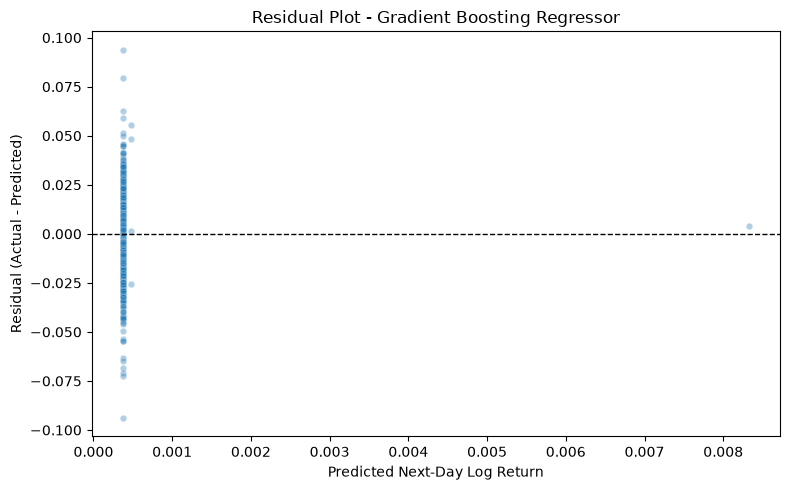

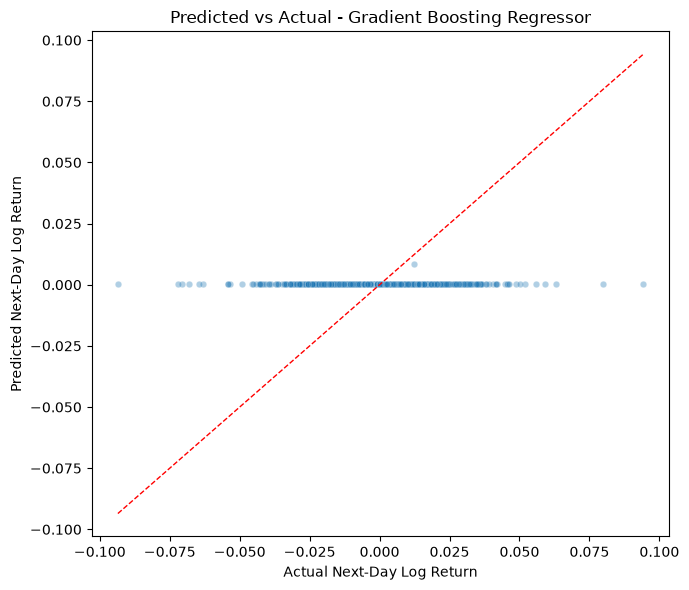

In [30]:
# The highest held-out R² model is used for the requested diagnostic plots.
best_model_name = model_results.iloc[0]["Model"]
best_predictions = {
    "Gradient Boosting Regressor": y_pred_gb,
    "Decision Tree Regressor": y_pred_dt,
    "Random Forest Regressor": y_pred_rf,
    "Linear Regression": y_pred_linear,
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso,
    "ElasticNet Regression": y_pred_elastic,
    "Polynomial Regression (degree 2)": y_pred_poly2,
    "Support Vector Regressor": y_pred_svr,
    "K-Nearest Neighbors Regressor": y_pred_knn
}
best_predictions_values = best_predictions[best_model_name]
residuals = y_test.to_numpy() - best_predictions_values

plt.figure(figsize=(8, 5))
sns.scatterplot(x=best_predictions_values, y=residuals, alpha=0.35, s=22)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title(f"Residual Plot - {best_model_name}")
plt.xlabel("Predicted Next-Day Log Return")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=best_predictions_values, alpha=0.35, s=22)
plot_min = min(y_test.min(), best_predictions_values.min())
plot_max = max(y_test.max(), best_predictions_values.max())
plt.plot([plot_min, plot_max], [plot_min, plot_max], color="red", linestyle="--", linewidth=1)
plt.title(f"Predicted vs Actual - {best_model_name}")
plt.xlabel("Actual Next-Day Log Return")
plt.ylabel("Predicted Next-Day Log Return")
plt.tight_layout()
plt.show()

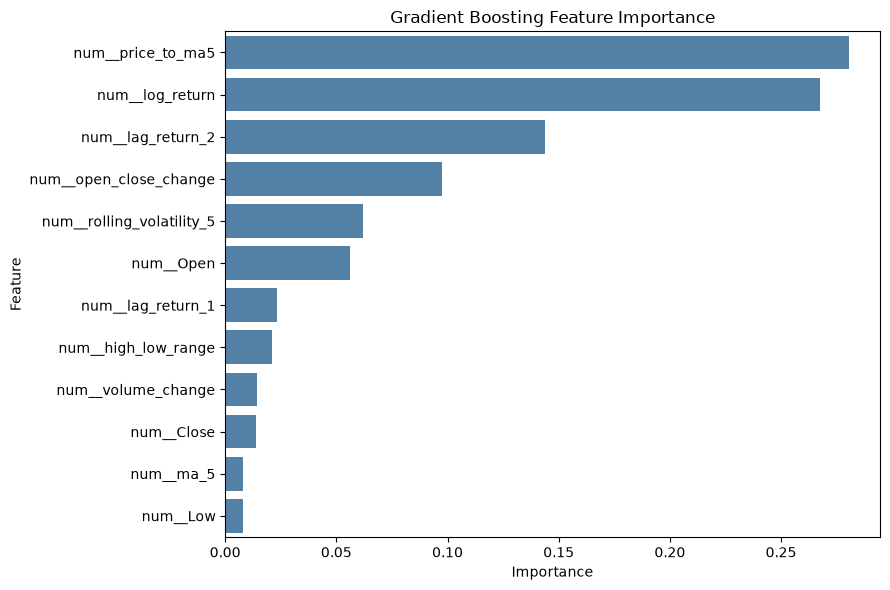

,Feature,Importance
13,num__price_to_ma5,0.280470
5,num__log_return,0.267287
9,num__lag_return_2,0.143925
7,num__open_close_change,0.097532
10,num__rolling_volatility_5,0.062164
0,num__Open,0.056093
8,num__lag_return_1,0.023390
6,num__high_low_range,0.021283
11,num__volume_change,0.014227
3,num__Close,0.014091


In [31]:
# Feature importance for the tree-based model selected for diagnostics.
importance_estimator = best_gb.named_steps["model"]
importance_preprocessor = best_gb.named_steps["preprocess"]
importance_df = pd.DataFrame({
    "Feature": importance_preprocessor.get_feature_names_out(),
    "Importance": importance_estimator.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=importance_df.head(12),
    x="Importance",
    y="Feature",
    color="steelblue"
)
plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

importance_df.head(12)